In [ ]:
import sys
from pathlib import Path

# Ensure repo root is on sys.path so `from tools...` imports work from any notebook subfolder.
_p = Path.cwd().resolve()
for _parent in [_p, *_p.parents]:
    if (_parent / 'tools' / 'search_tools.py').exists():
        sys.path.insert(0, str(_parent))
        break
del _p, _parent


In [14]:
%%capture --no-stderr
# %pip install "autogen-agentchat~=0.2.3"

# In Your OAI_CONFIG_LIST file, you must have two configs,
# one with:           "response_format": { "type": "text" }
# and the other with: "response_format": { "type": "json_object" }


[
    {"model": "gpt-4o-mini", "sk-REDACTED": "key go here", "response_format": {"type": "text"}},
]

In [15]:
import autogen
import os
from autogen.agentchat import UserProxyAgent
from autogen.agentchat.assistant_agent import AssistantAgent
from autogen.agentchat.groupchat import GroupChat
os.environ["SERPER_API_KEY"] = "7cf0b894e6058e57352767edc22aae2964190d38"
from tools.search_tools import SearchTools




In [16]:
from autogen import ConversableAgent
from autogen import register_function

import os
import json
import requests

def search_internet(query: str) -> str:
        """Useful to search the internet
        about a a given topic and return relevant results"""
        print("Searching the internet...")
        top_result_to_return = 5
        url = "https://google.serper.dev/search"
        payload = json.dumps(
            {"q": query, "num": top_result_to_return, "tbm": "nws"})
        headers = {
            'X-API-KEY': os.environ['SERPER_API_KEY'],
            'content-type': 'application/json'
        }
        response = requests.request("POST", url, headers=headers, data=payload)
        # check if there is an organic key
        if 'organic' not in response.json():
            return "Sorry, I couldn't find anything about that, there could be an error with you serper api key."
        else:
            results = response.json()['organic']
            string = []
            print("Results:", results[:top_result_to_return])
            for result in results[:top_result_to_return]:
                try:
                    # Attempt to extract the date
                    date = result.get('date', 'Date not available')
                    string.append('\n'.join([
                        f"Title: {result['title']}",
                        f"Link: {result['link']}",
                        f"Date: {date}",  # Include the date in the output
                        f"Snippet: {result['snippet']}",
                        "\n-----------------"
                    ]))
                except KeyError:
                    next

            return '\n'.join(string)


def get_web_data(agent_name:str, url:str) -> str:
    """get data from web page from a URL. Parameters: agent_name (str) - the name of the agent making the request; url (str) - the URL to fetch data from."""
    api_url = "https://scrape.serper.dev"
    api_key = '7cf0b894e6058e57352767edc22aae2964190d38'
    payload = json.dumps({"url": url})
    headers = {
        'X-API-KEY': api_key,
        'Content-Type': 'application/json'
    }
    response = requests.request("POST", api_url, headers=headers, data=payload)
    print("\033[92m" + f"{agent_name} -> webpage: {url}" + "\033[0m")
    print(response.text)
    return response.text



In [17]:
import asyncio
import autogen
import os
from typing import Optional, List, Dict, Tuple, Union

from autogen.agentchat.conversable_agent import ConversableAgent
from autogen.agentchat.groupchat import GroupChat

# Configure the language model
llm_config1 = {
    "config_list": [
        {
            "model": "nemotron",
            "api_type": "ollama",
            "client_host": "https://cb52ezau9b4upa-19123-81a72b623fcd2jyrme33.proxy.runpod.net",
        }
    ]
}

class MemoryAgent(ConversableAgent):
    def __init__(self, name, system_message, llm_config):
        super().__init__(name=name, system_message=system_message, llm_config=llm_config)
        self.memory = []

    def receive(self, message, sender, request_reply=None, silent=False):
        print(f"[{self.name}] Received message from {sender.name}: {message}")
        if isinstance(message, dict):
            # Check for tool-related keys
            if 'tool_calls' not in message and 'tool' not in message:
                role = message.get('role', '')
                content = message.get('content', '')
                # Store the received message in memory if it's not tool-related
                self.memory.append({"role": role, "content": content})
            else:
                print(f"Info: Tool-related message received and not stored in memory: {message}")
        else:
            print(f"Warning: Received a message without expected structure: {message}")
        # Call the parent class's receive method to handle the message
        super().receive(message, sender, request_reply, silent)

    def send(self, message, recipient, request_reply=None, silent=False):
        print(f"[{self.name}] Sending message to {recipient.name}: {message}")
        if isinstance(message, dict):
            # Check for tool-related keys
            if 'tool_calls' not in message and 'tool' not in message:
                role = message.get('role', '')
                content = message.get('content', '')
                # Store the agent's response in memory if it's not tool-related
                self.memory.append({"role": role, "content": content})
            else:
                print(f"Info: Tool-related message sent and not stored in memory: {message}")
        else:
            print(f"Warning: Sending a message without expected structure: {message}")
        # Call the parent class's send method to send the message
        super().send(message, recipient, request_reply, silent)

    def generate_response(self, messages):
        # Limit to the last 10 messages from memory
        recent_memory = self.memory[-10:]
        # Prepare the conversation context
        conversation = [{"role": "system", "content": self.system_message}] + recent_memory + messages
        # Generate a response using the language model
        response = self.llm.generate(conversation)
        # Store the response in memory
        self.memory.append({"role": "assistant", "content": response})
        return response




def is_termination_msg(content) -> bool:
    have_content = content.get("content", None) is not None
    if have_content and "TERMINATE" in content["content"]:
        return True
    return False

user_proxy = autogen.UserProxyAgent(
    name="User_proxy",
    system_message=(
        "You are a human admin overseeing a group chat og language experts "
        "Your role is to monitor the discussion and terminate the chat when the Leader agent sends a message containing the keyword 'TERMINATE'."
    ),
    code_execution_config=False,
    human_input_mode="NEVER",
    is_termination_msg=lambda x: x.get("content", "").find("TERMINATE") >= 0,
    llm_config=llm_config1,
)

# Problem Statement
# problem_statement = (
#     "Our fashion-based company is experiencing significant supply chain disruptions "
#     "due to recent events in Bangladesh and the Red Sea crisis. These issues have led to "
#     "shipment delays, container rollovers, and difficulties in fulfilling order commitments "
#     "to major clients such as Walmart, TJ Maxx, and Nordstrom. To circumvent on-water delays, "
#     "we've resorted to expensive air shipments, severely impacting our profitability. "
#     "We require an exact solution that includes specific logistics routes and strategies for "
#     "managing and relocating production to ensure timely deliveries and maintain profitability."
# )

# Adjusted System Messages for Agents

AgentA = MemoryAgent(
    name="Algebra Specialist",
    system_message=(
        "Role: Algebra Specialist in a collaborative mathematical problem-solving task.\n"
        "\n"
        "Context:\n"
        "You are an expert in algebra, responsible for analyzing and solving algebraic equations and expressions. Your task is to address the algebraic condition of the problem and share your findings with the team.\n"
        "you are in a groupchat with 5 mathematical experts who are solving individual math problems and trying to find the value of N satisfying all of them.\n"
        "\n"
        "Instructions:\n"
        "- solve only and only problem one\n"
        "- Share your reasoning and results in the group chat.\n"
        "- Be open to adjusting your conclusions based on input from others.\n"
        "\n"
        "Note:\n"
        "- Focus on your specialization but consider information from other agents.\n"
        "- Communicate clearly and professionally.\n"
        "- Avoid any unrelated discussions."
    ),
    llm_config=llm_config1,
)


AgentB = MemoryAgent(
    name="Number theory specialist",
    system_message=(
        "Role: Number Theory Specialist in a collaborative mathematical problem-solving task.\n"
        "\n"
        "Context:\n"
        "You are an expert in number theory, focusing on prime numbers, congruences, and related concepts. Your task is to address the number theory condition of the problem and share your findings with the team.\n"
        "- you are in a groupchat with 5 mathematical experts who are solving individual math problems and trying to find the value of N satisfying all of them.\n"
        "\n"
        "Instructions:\n"
        "- solve only and only problem two. \n"
        "- Share your reasoning and potential values of \( N \) in the group chat.\n"
        "- Be open to adjusting your conclusions based on input from others.\n"
        "\n"
        "Note:\n"
        "- Focus on your specialization but consider information from other agents.\n"
        "- Communicate clearly and professionally.\n"
        "- Avoid any unrelated discussions."
    ),
    llm_config=llm_config1,
)



AgentC = MemoryAgent(
    name="Combinatorics specialist",
    system_message=(
        "Role: Combinatorics Specialist in a collaborative mathematical problem-solving task.\n"
        "\n"
        "Context:\n"
        "You are an expert in combinatorics, dealing with combinations, permutations, and related concepts. Your task is to address the combinatorics condition of the problem and share your findings with the team.\n"
        "- you are in a groupchat with 5 mathematical experts who are solving individual math problems and trying to find the value of N satisfying all of them.\n"
        "\n"
        "Instructions:\n"
        "- Solve only and only problem three"
        "- Find integer values of \( N \) that satisfy the problem\n"
        "- Share your reasoning and results in the group chat.\n"
        "- Be open to adjusting your conclusions based on input from others.\n"
        "\n"
        "Note:\n"
        "- Focus on your specialization but consider information from other agents.\n"
        "- Communicate clearly and professionally.\n"
        "- Avoid any unrelated discussions."
    ),
    llm_config=llm_config1,
)



AgentD = MemoryAgent(
    name="Calculus Specialist",
    system_message=(
        "Role: Calculus Specialist in a collaborative mathematical problem-solving task.\n"
        "\n"
        "Context:\n"
        "You are an expert in calculus, particularly in integration and analysis of functions. Your task is to address the calculus condition of the problem and share your findings with the team.\n"
        "- you are in a groupchat with 5 mathematical experts who are solving individual math problems and trying to find the value of N satisfying all of them.\n"
        "\n"
        "Instructions:\n"
        "- solve only and only problem four. \n"
        "- Share your reasoning and potential values of \( N \) in the group chat.\n"
        "- Be open to adjusting your conclusions based on input from others.\n"
        "\n"
        "Note:\n"
        "- Focus on your specialization but consider information from other agents.\n"
        "- Communicate clearly and professionally.\n"
        "- Avoid any unrelated discussions."
    ),
    llm_config=llm_config1,
)

AgentE = MemoryAgent(
    name="Geometry Specialist",
    system_message=(
        "Role: Geometry Specialist in a collaborative mathematical problem-solving task.\n"
        "\n"
        "Context:\n"
        "You are an expert in geometry, focusing on properties of shapes and angles. Your task is to address the geometry condition of the problem and share your findings with the team.\n"
        "- you are in a groupchat with 5 mathematical experts who are solving individual math problems and trying to find the value of N satisfying all of them.\n"
        "\n"
        "Instructions:\n"
        "- solve only and only problem five. \n"
        "- Share your reasoning and potential values of \( N \) in the group chat.\n"
        "- Be open to adjusting your conclusions based on input from others.\n"
        "\n"
        "Note:\n"
        "- Focus on your specialization but consider information from other agents.\n"
        "- Communicate clearly and professionally.\n"
        "- Avoid any unrelated discussions."
    ),
    llm_config=llm_config1,
)


AgentF = MemoryAgent(
    name="Leader",
    system_message=(
        "Role: Team Leader overseeing the collaborative mathematical problem-solving task.\n"
        "\n"
        "you are in a groupchat with 5 mathematical experts who are solving individual math problems and trying to find the value of N satisfying all 5 of the equations"
        "you are responsible for giving out the final answer. YOU DO NOT KNOW ANY MATHEMATICS AND CANNOT SOLVE ANY OF THE PROBLEMS SO WAIT FOR RESPONSES OF ALL EXPERTS"
        "\n"
        "Instructions:\n"
        "- ONLY GIVE THE FINAL OUTPUT ON VALUE OF N WHEN ALL AGENTS HAVE GIVEN THEIR RESPONSE. THERE ARE 5 PROBLEMS SO YOU WILL GET 5 RESPONSES ABOUT THE POSSIBLE VALUES OF N"
        "- If unable to find a integer value terminate chat with saying no integer value found"
        "- **Include the keyword 'TERMINATE' at the end of your final message** to signal the end of the group chat.\n"
        "- Avoid introducing new mathematical conditions not provided in the problem.\n"
        "\n"
        "Note:\n"
        "- Ensure the final answer is accurate and justified.\n"
        "- Avoid any unrelated discussions."
    ),
    llm_config=llm_config1,
)

# (Optional) Tool Executor Agent if needed
Agent5 = ConversableAgent(
    name="Tool_executor",
    system_message=(
        "Role: Tool Executor responsible for running approved tools.\n"
        "\n"
        "Guidelines:\n"
        "- Execute tasks as requested by other agents, within the scope of approved tools.\n"
        "- Provide results promptly and accurately.\n"
        "\n"
        "Note:\n"
        "- Ensure all tool usage complies with company policies.\n"
        "- Maintain clear communication with requesting agents."
    ),
    llm_config=llm_config1,
)

In [18]:
# from autogen import register_function



# Agent0.register_for_llm(name = "Browse_internet", description = "search the internet")(search_internet)

# # Agent1.register_for_llm(name = "Browse_internet", description = "search the internet")(search_internet)

# # Agent2.register_for_llm(name = "Browse_internet", description = "search the internet")(search_internet)

# # Agent3.register_for_llm(name = "Browse_internet", description = "search the internet")(search_internet)

# user_proxy.register_for_execution(name="Browse_internet")(search_internet)


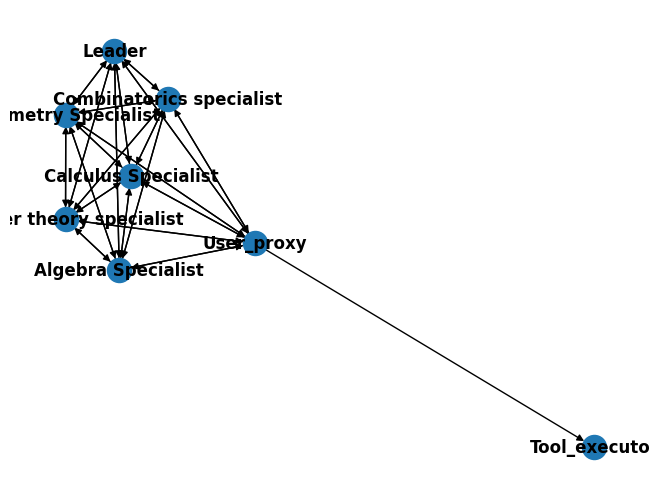

In [19]:
from autogen.graph_utils import visualize_speaker_transitions_dict
# Define your agents
agents = [AgentA, AgentB, AgentC, AgentD, AgentE, user_proxy, Agent5, AgentF]

# Initialize the allowed speaker transitions dictionary
allowed_speaker_transitions_dict = {}

# Set up transitions for each agent
for agent in agents:
    if agent == Agent5:
        # Agent5 cannot send messages to any agent
        allowed_speaker_transitions_dict[agent] = []
    else:
        # Other agents can send messages to all agents except themselves and Agent5
        allowed_speaker_transitions_dict[agent] = [
            other_agent for other_agent in agents
            if other_agent != agent and other_agent != Agent5
        ]

# Allow user_proxy to send messages to Agent5
allowed_speaker_transitions_dict[user_proxy].append(Agent5)

# Visualize the transitions
visualize_speaker_transitions_dict(allowed_speaker_transitions_dict, agents)


In [20]:
def is_termination_msg(content) -> bool:
    have_content = content.get("content", None) is not None
    if have_content and "TERMINATE" in content["content"]:
        return True
    return False


agents.append(user_proxy)

group_chat = GroupChat(
    agents=agents,
    messages=[],
    max_round=500,
    allowed_or_disallowed_speaker_transitions=allowed_speaker_transitions_dict,
    speaker_transitions_type="allowed",
)
# Create the manager
manager = autogen.GroupChatManager(
    groupchat=group_chat,
    system_message="make the first speaker the leader agent",
    llm_config=llm_config1,
    is_termination_msg=lambda x: x.get("content", "").find("TERMINATE") >= 0,
    code_execution_config=False,
)


In [21]:
# from autogen import register_function


# register_function(
#     search_internet,
#     caller=Agent0,  # The assistant agent can suggest calls to the calculator.
#     executor=Agent5,  # The user proxy agent can execute the calculator calls.
#     name="Browse_internet",  # By default, the function name is used as the tool name.
#     description="Browse the internet using this tool",  # A description of the tool.
# )

# register_function(
#     search_internet,
#     caller=Agent1,  # The assistant agent can suggest calls to the calculator.
#     executor=Agent5,  # The user proxy agent can execute the calculator calls.
#     name="Browse_internet",  # By default, the function name is used as the tool name.
#     description="Browse the internet using this tool",  # A description of the tool.
# )

# register_function(
#     search_internet,
#     caller=Agent2,  # The assistant agent can suggest calls to the calculator.
#     executor=Agent5,  # The user proxy agent can execute the calculator calls.
#     name="Browse_internet",  # By default, the function name is used as the tool name.
#     description="Browse the internet using this tool",  # A description of the tool.
# )

# register_function(
#     search_internet,
#     caller=Agent3,  # The assistant agent can suggest calls to the calculator.
#     executor=Agent5,  # The user proxy agent can execute the calculator calls.
#     name="Browse_internet",  # By default, the function name is used as the tool name.
#     description="Browse the internet using this tool",  # A description of the tool.
# )


# register_function(
#     get_web_data,
#     caller=Agent0,  # The assistant agent can suggest calls to the calculator.
#     executor=Agent5,  # The user proxy agent can execute the calculator calls.
#     name="Browse_website",  # By default, the function name is used as the tool name.
#     description="Browse a website you like using this tool",  # A description of the tool.
# )

# register_function(
#     get_web_data,
#     caller=Agent1,  # The assistant agent can suggest calls to the calculator.
#     executor=Agent5,  # The user proxy agent can execute the calculator calls.
#     name="Browse_website",  # By default, the function name is used as the tool name.
#     description="Browse a website you like using this tool",  # A description of the tool.
# )

# register_function(
#     get_web_data,
#     caller=Agent2,  # The assistant agent can suggest calls to the calculator.
#     executor=Agent5,  # The user proxy agent can execute the calculator calls.
#     name="Browse_website",  # By default, the function name is used as the tool name.
#     description="Browse a website you like using this tool",  # A description of the tool.
# )

# register_function(
#     get_web_data,
#     caller=Agent3,  # The assistant agent can suggest calls to the calculator.
#     executor=Agent5,  # The user proxy agent can execute the calculator calls.
#     name="Browse_website",  # By default, the function name is used as the tool name.
#     description="Browse a website you like using this tool",  # A description of the tool.
# )



In [22]:
# chat_result = user_proxy.initiate_chat(Agent0, message="search internet about google. Use production Manager first")

In [24]:
# Initial message
initial_message = (
                    "Please work on findind the value of N which satisfies all 5 problems following collaboration between all experts \n"
                    "- problem one - Find possible integer values of \( N \) based on the equation \( 2x^3 - 5x^2 + x - 7 = 0 \) with \( x = \sqrt{N} \).\n"
                    "- problem two - Identify prime numbers \( N \) such that \( N \) and \( N + 2 \) are both prime (twin primes) and Ensure that \( N \equiv 3 \mod 4 \). \n"
                    "- problem three - Solve for \( N \) in the equation \( \binom{N}{3} = 364 \). \n"
                    "- problem four - Evaluate the definite integral \( \int_{0}^{\pi} \sin(Nx) \, dx = 0 \). \n"
                    "- problem five - Determine the integer values of \( N \) such that a regular polygon with \( N \) sides has an internal angle that is an integer number of degrees. Use the formula \( \alpha = \left(1 - \frac{2}{N}\right) \times 180^\circ \) for the internal angle.\n"
)


# Initiate the conversation 
user_proxy.initiate_chat(manager, message=initial_message)

User_proxy (to chat_manager):

Please work on findind the value of N which satisfies all 5 problems following collaboration between all experts 
- problem one - Find possible integer values of \( N \) based on the equation \( 2x^3 - 5x^2 + x - 7 = 0 \) with \( x = \sqrt{N} \).
- problem two - Identify prime numbers \( N \) such that \( N \) and \( N + 2 \) are both prime (twin primes) and Ensure that \( N \equiv 3 \mod 4 \). 
- problem three - Solve for \( N \) in the equation \(inom{N}{3} = 364 \). 
- problem four - Evaluate the definite integral \( \int_{0}^{\pi} \sin(Nx) \, dx = 0 \). 
ight) 	imes 180^\circ \) for the internal angle. \( N \) such that a regular polygon with \( N \) sides has an internal angle that is an integer number of degrees. Use the formula \( lpha = \left(1 - rac{2}{N}


--------------------------------------------------------------------------------
[Algebra Specialist] Received message from chat_manager: {'content': 'Please work on findind the value of N w

RuntimeError: Ollama exception occurred: Bad Request


In [ ]:
last_message = group_chat.messages[-1] if group_chat.messages else None
if last_message:
    print("Final Message Content:", last_message['content'])

Final Message Content: **ADMINISTRATOR'S RESPONSE**

**Group Chat Post**

Hello Team,

I have been monitoring our discussion on the multidisciplinary problem involving various constraints across Algebra, Number Theory, Combinatorics, Calculus, and Geometry. I would like to commend each of you for your in-depth analyses and collaborative approach to tackling this complex challenge.

**CONFIRMATION OF CASE CLOSURE**

Following the Team Leader's comprehensive summary, I hereby **CONFIRM THAT THIS CASE IS NOW CLOSED**. The conclusion that no single universal integer value of \( N \) satisfies all problems, along with the identification of discipline-specific solutions, is well-documented and understood by all team members.

**KEY TAKEAWAYS FOR FUTURE PROBLEMS**

As highlighted in the conclusion:
1. **Problem Statement Refinement**: Future problem statements will strive to explicitly define acceptable variable types.
2. **Disciplinary Alignment**: The team acknowledges potential discrepanci

In [ ]:
def save_conversation_to_file(groupchat, filename="chat.txt"):
    """
    Save the entire conversation history to a specified file.

    Args:
        groupchat (GroupChat): The GroupChat instance containing the messages.
        filename (str): The name of the file to save the conversation history.
    """
    if not groupchat.messages:
        print("No messages in the group chat to save.")
        return

    # Compile the conversation history
    conversation_history = "\n".join(
        f"{msg['role']}: {msg['content']}" for msg in groupchat.messages
    )

    # Write the conversation history to the file
    with open(filename, "w", encoding="utf-8") as file:
        file.write(conversation_history)

    print(f"Conversation history saved to {filename}")
    
save_conversation_to_file(group_chat, filename="chat.txt")


Conversation history saved to chat.txt
